# Runverve — Wearable Fatigue Prediction Prototype

**AI/ML Engineer Intern Submission**

This prototype predicts **Low, Moderate, or High fatigue** from synthetic wearable-style physiological, sleep, activity, and hydration-proxy features using a supervised Random Forest classifier.

> The dataset is synthetic. This is a technical prototype, not a clinically validated fatigue detector or medical device.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
df = pd.read_csv("synthetic_wearable_fatigue.csv")

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nClass distribution:")
print(df["fatigue_level"].value_counts(normalize=True).round(3))

Shape: (1500, 12)

Missing values:
age                      0
resting_hr_bpm           0
hrv_rmssd_ms            37
sleep_hours             37
steps                    0
activity_minutes         0
skin_temperature_c      37
respiratory_rate_bpm     0
hydration_proxy         37
sleep_debt_hours         0
previous_day_load        0
fatigue_level            0
dtype: int64

Class distribution:
fatigue_level
Moderate    0.34
Low         0.34
High        0.32
Name: proportion, dtype: float64


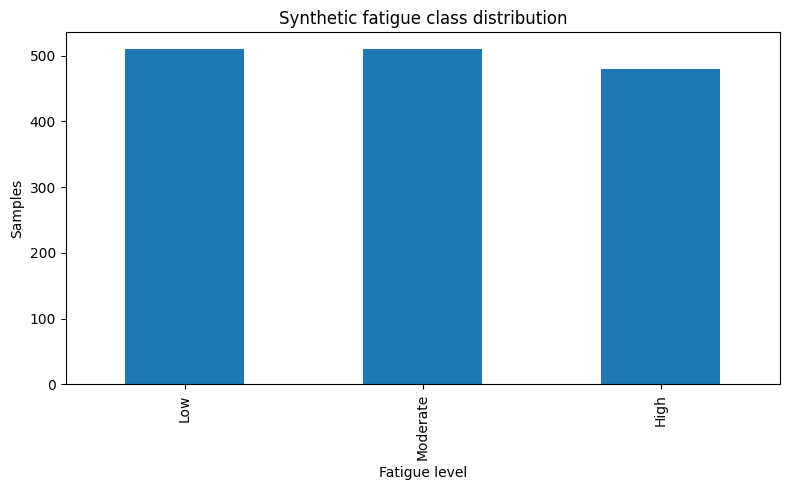

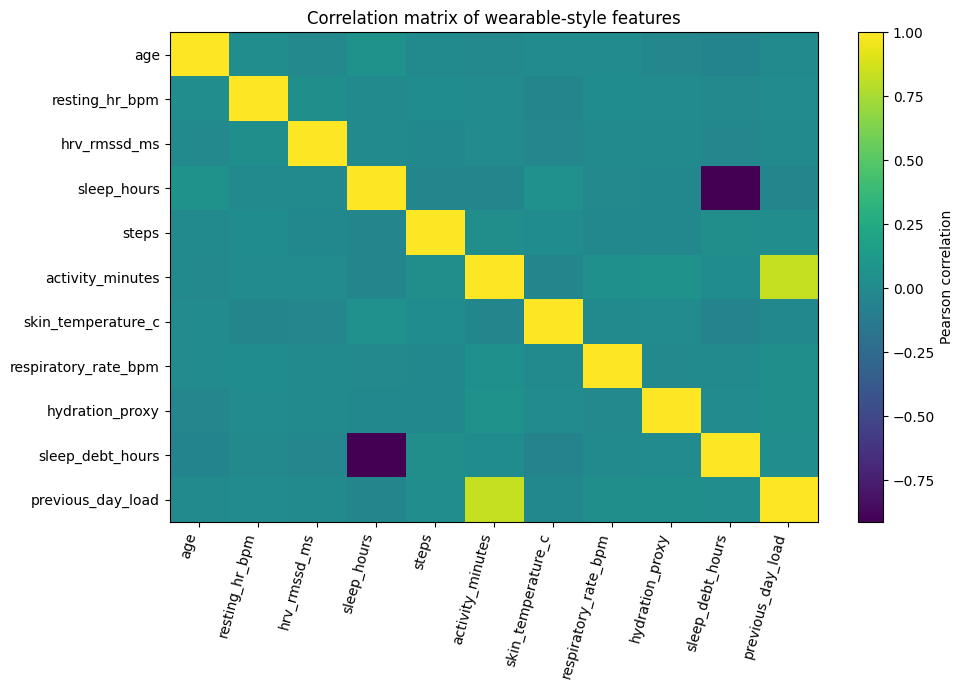

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
df["fatigue_level"].value_counts().reindex(["Low", "Moderate", "High"]).plot(kind="bar", ax=ax)
ax.set_title("Synthetic fatigue class distribution")
ax.set_xlabel("Fatigue level")
ax.set_ylabel("Samples")
plt.tight_layout()
plt.show()

numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=75, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
ax.set_title("Correlation matrix of wearable-style features")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

## Feature selection and preprocessing

The target column is excluded from the feature matrix. Missing numeric values are median-imputed. A stratified 80/20 train-test split preserves class proportions.Random Forest is used because it can model nonlinear relationships and provides useful feature-importance methods for an initial prototype.

In [4]:
target = "fatigue_level"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features)
])

model = RandomForestClassifier(
    n_estimators=350,
    max_depth=9,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("Macro F1:", round(f1_score(y_test, pred, average="macro"), 3))
print(classification_report(y_test, pred, digits=3))

Accuracy: 0.777
Macro F1: 0.781
              precision    recall  f1-score   support

        High      0.844     0.844     0.844        96
         Low      0.874     0.745     0.804       102
    Moderate      0.650     0.745     0.694       102

    accuracy                          0.777       300
   macro avg      0.789     0.778     0.781       300
weighted avg      0.788     0.777     0.779       300



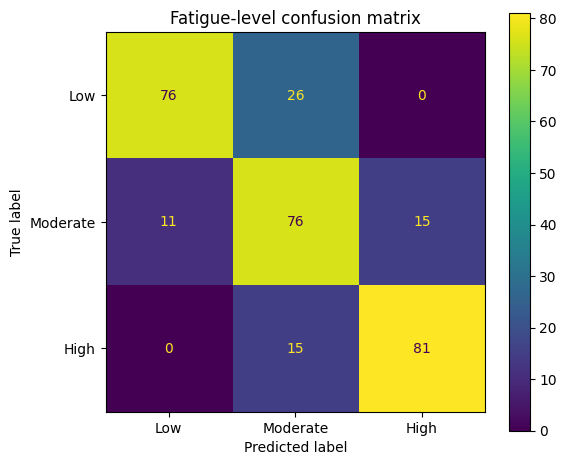

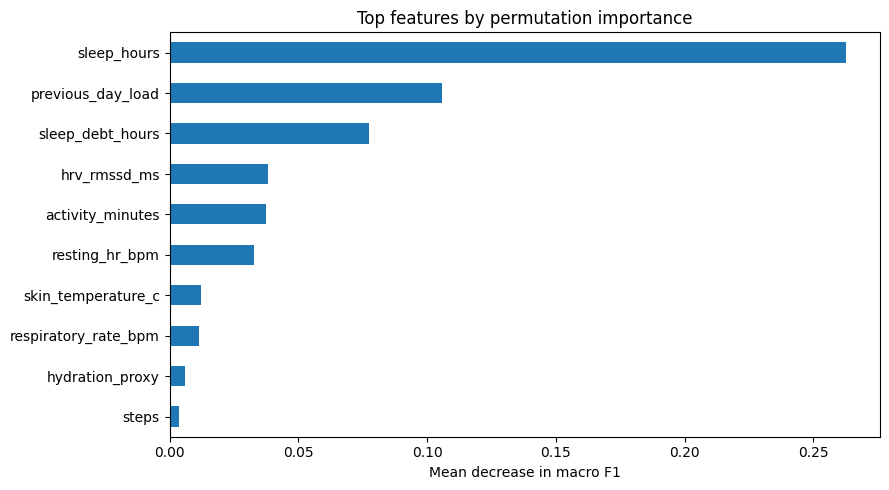

sleep_hours             0.262740
previous_day_load       0.105615
sleep_debt_hours        0.077407
hrv_rmssd_ms            0.038314
activity_minutes        0.037628
resting_hr_bpm          0.032585
skin_temperature_c      0.012377
respiratory_rate_bpm    0.011252
hydration_proxy         0.005912
steps                   0.003483
dtype: float64


In [9]:
cm = confusion_matrix(y_test, pred, labels=["Low", "Moderate", "High"])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Moderate", "High"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
ax.set_title("Fatigue-level confusion matrix")
plt.tight_layout()
plt.show()

result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
importance.head(10).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top features by permutation importance")
ax.set_xlabel("Mean decrease in macro F1")
plt.tight_layout()
plt.show()

print(importance.head(10))

In [8]:
sample = X_test.iloc[[0]]

prediction = pipeline.predict(sample)[0]

probabilities = pd.Series(
    pipeline.predict_proba(sample)[0],
    index=pipeline.named_steps["model"].classes_
).sort_values(ascending=False)

print("Predicted fatigue:", prediction)
print("\nClass probabilities:")
print(probabilities.round(3))

Predicted fatigue: Low

Class probabilities:
Low         0.938
Moderate    0.060
High        0.003
dtype: float64


## Runverve Digital Twin integration

A future Runverve implementation could maintain a personalized baseline rather than relying only on one global model prediction.

```text
Wearable sensors--> BLE / mobile ingestion-->Feature extraction + sensor-quality checks-->Fatigue model + personal baseline-->Digital Twin state
-->Recovery / training recommendation
```
With real longitudinal data, the next steps would include subject-aware validation, temporal features, model calibration, sensor-quality monitoring, drift detection, privacy controls, and prospective validation.

### Conclusion

This prototype demonstrates the requested workflow:

**data → preprocessing → feature analysis → supervised model → evaluation → inference → Digital Twin integration**